In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from dynamics import *
from scipy import stats

In [2]:
#create invasion fitness matrix for invader-driven case
def make_fit(invader):
    k = len(invader)
    fit = np.zeros((k,k))
    for i in range (0, k):
        for j in range (0, k):
            if i != j:
                fit[i,j] = invader[i]
                
    return fit

In [19]:
invader1 = np.array([-0.3, -0.35, -0.95, 0.75, 0.9, -0.6, 0.1, 0.83, 0.85, 0.64, 0.7, 0.66])
invader2 = np.array([-0.3, -0.35, -0.95, 0.75, 0.9, -0.6, 0.1, 0.83, 0.85, 0.64, 0.7, 0.66, 0.5, 0.95, 0.72])

In [20]:
n_array = np.array([12, 15])
#invader = (np.random.rand(n) - 1/2)*2
invader_array = np.array([invader1, invader2], dtype = object)
fit_array = np.array([0, 0], dtype = object)
u0_array = np.array([0, 0], dtype = object)
idx_array = np.array([0, 0], dtype = object)
frequency_array = np.array([0, 0], dtype = object)

for i in range (0, 2):
    invader = invader_array[i]
    fit = make_fit(invader)
    fit_array[i] = fit
        
    #compute the dynamics and number of survival strains
    u0 = np.random.rand(n_array[i]) #create random intitial state
    u0 = u0/sum(u0)
    u0_array[i] = u0
    A, resultat, nc = simu(T = 1500, fit = fit, z0 = u0)
    frequency = resultat.y[:,-1]
    frequency_array[i] = frequency

    #persistent species
    idx = np.where(frequency > 1e-4)[0] 
    idx_array[i] = idx

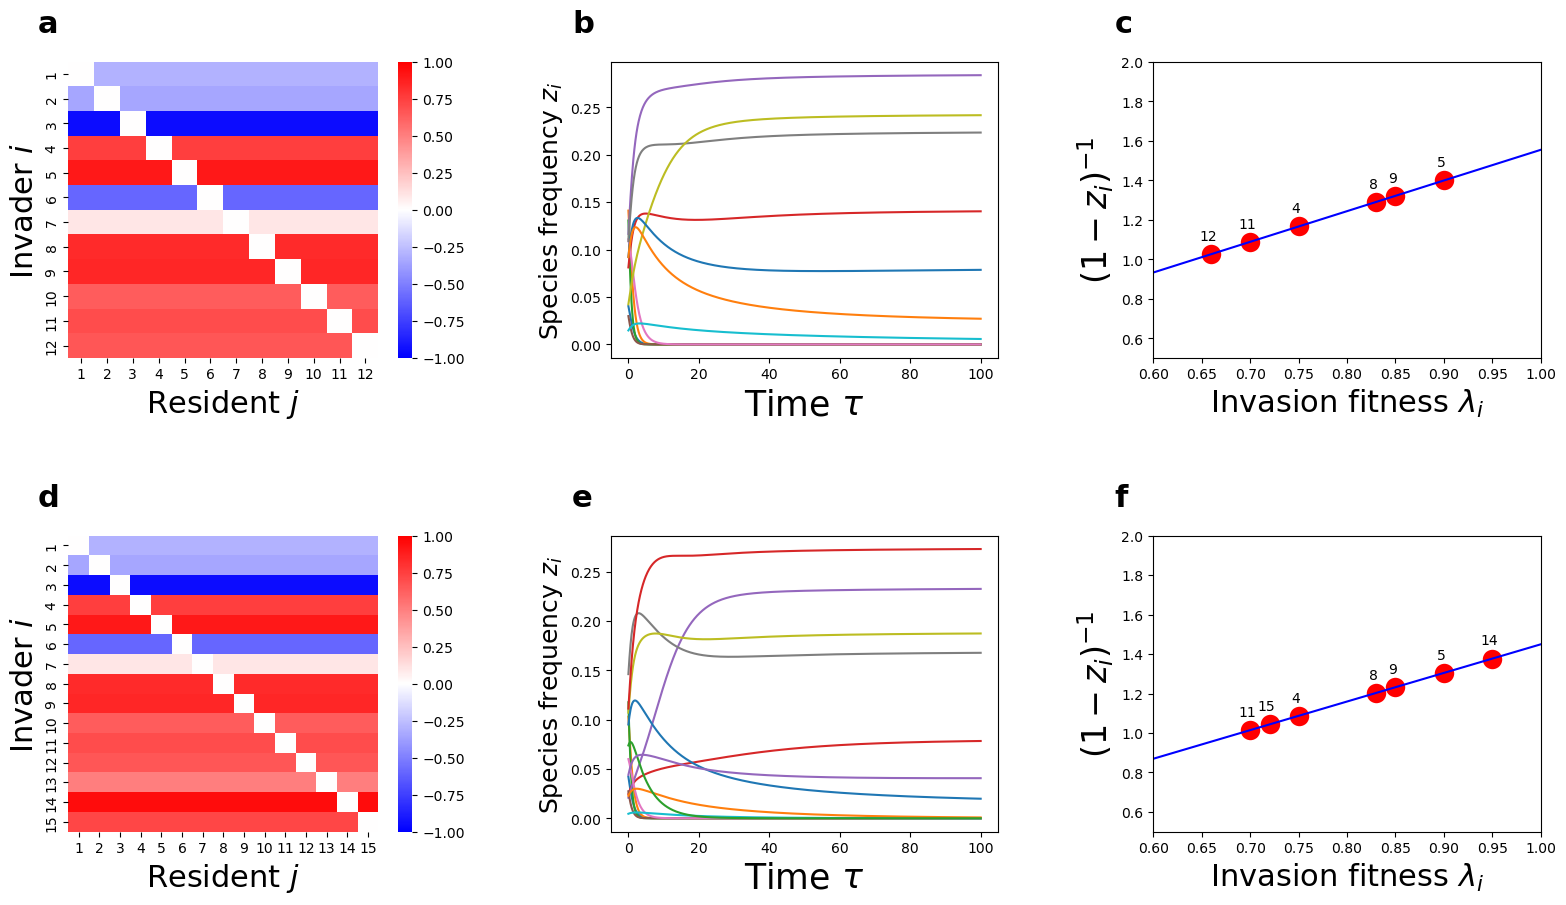

In [21]:
T = 250
details = T*10
    
# Figure
fig, ax = plt.subplots(2, 3, figsize = (19, 10))
plt.subplots_adjust(wspace = 0.4, hspace = 0.6)
label = np.array([['a', 'b', 'c'], ['d', 'e', 'f']])

for i in range (0, 2):
    fit = fit_array[i]
    n = n_array[i]
    range_strain = np.linspace(1, n, n)

    # Panel a
    sns.heatmap(fit, ax = ax[i,0], xticklabels=range(1, n+1), yticklabels=range(1, n+1), 
                vmin = -1, center = 0, vmax = 1, cmap = "bwr", cbar = True)
    ax[i,0].set_xlabel("Resident $j$", fontsize = 22)
    ax[i,0].set_ylabel("Invader $i$", fontsize = 22)

    # Panel b
    u0 = u0_array[i]
    result, ax[i, 1] = plot_dynamics(T = 100, fit = fit, z0 = u0, ax = ax[i,1])
    ax[i, 1].set_ylabel('Species frequency $z_i$', fontsize = 18)
    ax[i, 1].title.set_visible(False)

    # Panel c
    inverse = []
    idx = np.array(idx_array[i])
    invader = invader_array[i]
    frequency = frequency_array[i]
    for j in range (0, n):
        temp = 1/(1- frequency[j])
        inverse.append(temp)
    x = np.linspace(0, 2, 100)
    # Linear regression
    invader_survive = np.array([invader[k] for k in idx])
    inverse_survive = np.array([inverse[k] for k in idx])
        
    slope, intercept, r, p, std_err = stats.linregress(invader_survive, inverse_survive)

    ax[i,2].scatter(invader_survive, inverse_survive, linewidth = 8, color = 'red') #survival ones

    ax[i,2].plot(x, slope*x + intercept, color = 'blue')

    ax[i, 2].set_xlabel('Invasion fitness $\\lambda_i$', fontsize = 22)
    ax[i, 2].set_ylabel('$(1-z_i)^{-1}$', fontsize = 24)
    ax[i, 2].set_xlabel('Invasion fitness $\\lambda_i$', fontsize = 22)


    ax[i, 2].set_xlim(0.6, 1)
    ax[i, 2].set_ylim(0.5, 2)

    for xi, yi, name in zip(invader_survive, inverse_survive, idx +1):
        ax[i, 2].annotate(name, (xi, yi), xytext=(-2, 8), textcoords="offset points", fontsize=10, ha="center", va="bottom")
    
for i in range (0, 2):
    for j in range (0, 3):
        ax[i,j].text(-0.1, 1.1, '{}'.format(label[i,j]), transform=ax[i,j].transAxes, size=22, weight='bold')
    
plt.show()

In [22]:
[s1, s2] = [set(idx_array[0]), set(idx_array[1])]
common = s1&s2
common = np.array(list(common))
print(common)

[ 3  4  7  8 10]


In [23]:
# function computing equilibrium
def compute_q_star(lambdas):
    k = len(lambdas)
    sum_inv_lambda = sum(1.0 / lam for lam in lambdas)
    q_star = (k - 1) / sum_inv_lambda
    return q_star

def compute_z(lambdas):
    q_star = compute_q_star(lambdas)
    z = [1 - q_star / lam for lam in lambdas]
    return z

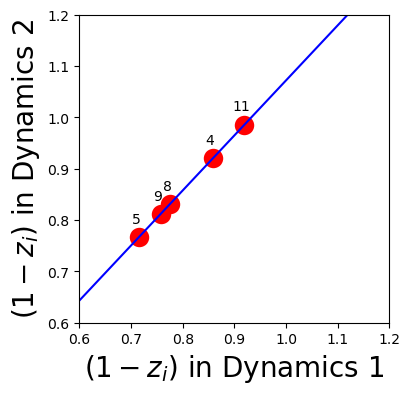

In [25]:
fig, ax = plt.subplots(1, 1, figsize = (4, 4))

term_array = np.array([0,0], dtype = object)
x = np.linspace(0, 2, 100)

for i in range (0,2):
    term = []
    invader = invader_array[i]
    idx = np.array(idx_array[i])
    lambda_survive = [invader[strain] for strain in idx]
    ss = compute_z(lambda_survive)
    
    ss_common = []
    for j in range (0, len(idx)):
        if idx[j] in common:
            ss_common.append(ss[j])
    
    term = [1-ss_common[j] for j in range (0, len(ss_common))]
    term_array[i] = term
    
#linearity between common species between 2 sets
slope_c, intercept_c, r, p, std_err = stats.linregress(term_array[0], term_array[1])
ax.scatter(term_array[0], term_array[1], linewidth = 8, color = 'red') #survival ones
ax.plot(x, slope_c*x + intercept_c, color = 'blue')
ax.set_xlabel('$(1-z_i)$ in Dynamics 1', fontsize = 20)
ax.set_ylabel('$(1-z_i)$ in Dynamics 2', fontsize = 20)
ax.set_xlim(0.6, 1.2)
ax.set_ylim(0.6, 1.2)

for xi, yi, name in zip(term_array[0], term_array[1], common +1):
    ax.annotate(name, (xi, yi), xytext=(-2, 8), textcoords="offset points", fontsize=10, ha="center", va="bottom")